In [8]:
from google.colab import files
import pandas as pd

# Upload the CSV file
uploaded = files.upload()

# Read the CSV file into a DataFrame after uploading
for filename in uploaded.keys():
  df = pd.read_csv(filename)
  print(f"File '{filename}' has been successfully uploaded and read.")
  display(df.head())
  break # Process only the first file if multiple files are uploaded

Saving facebook_reviews.csv to facebook_reviews.csv
File 'facebook_reviews.csv' has been successfully uploaded and read.


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,b290c064-f2af-4509-b425-0b6a1bca51a9,Angela Larsen,all these new updates are causing so many glit...,2,10,556.1.0.63.64,2026-04-20 04:01:19,556.1.0.63.64
1,b03e2730-8311-4dab-80e3-a6447013913d,Angelle Rivera,"Some post are missing, please fix the system. ...",1,3,556.1.0.63.64,2026-04-16 01:58:34,556.1.0.63.64
2,16db6557-41b3-470b-9cfd-b960fbb52bb8,Westerson Pakyntein,This is the worst app ever. I have changed my ...,1,4,555.0.0.49.59,2026-04-13 05:04:50,555.0.0.49.59
3,09ea8f0a-a833-439b-9323-224c101a41f0,Janet H Brasher,love Facebook. enjoy reading and seeing lots o...,2,1,555.0.0.49.59,2026-04-09 05:32:58,555.0.0.49.59
4,69629bec-26c0-4c1a-82c9-ab37e9c68a8b,Shawn Poirier,"everything is fine , just getting the hang of ...",5,5,554.0.0.57.70,2026-04-05 07:30:05,554.0.0.57.70


In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources (run only once)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string cases
        return ""
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove special characters
    words = text.split() # Split into words
    words = [word for word in words if word not in stop_words] # Remove stop words
    words = [lemmatizer.lemmatize(word) for word in words] # Lemmatize words
    return ' '.join(words)

# Apply preprocessing to the 'content' column
df['cleaned_content'] = df['content'].apply(preprocess_text)

print("Data after preprocessing (first 5 rows):")
display(df[['content', 'cleaned_content', 'score']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Data after preprocessing (first 5 rows):


,content,cleaned_content,score
0,all these new updates are causing so many glit...,new update causing many glitch,2
1,"Some post are missing, please fix the system. ...",post missing please fix system annoying new ve...,1
2,This is the worst app ever. I have changed my ...,worst app ever changed login password multiple...,1
3,love Facebook. enjoy reading and seeing lots o...,love facebook enjoy reading seeing lot thing m...,2
4,"everything is fine , just getting the hang of ...",everything fine getting hang thing would nice ...,5


In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Remove rows with empty 'cleaned_content' or NaN 'score'
df_processed = df.dropna(subset=['cleaned_content', 'score']).copy()

# Convert 'score' to integer (if needed) and normalize to 0-index (e.g., 1-5 stars to 0-4)
# Assuming scores from 1 to 5
df_processed['score'] = df_processed['score'].astype(int) - 1
num_classes = df_processed['score'].nunique()

# Set parameters for tokenization and padding
max_words = 10000  # Maximum number of unique words to keep in the dictionary
max_len = 100    # Maximum sequence length (shorter reviews will be padded, longer ones will be truncated)

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df_processed['cleaned_content'])

# Convert text to integer sequences
X = tokenizer.texts_to_sequences(df_processed['cleaned_content'])

# Pad sequences to a uniform length
X = pad_sequences(X, maxlen=max_len)

y = df_processed['score'].values

print(f"Shape of X after padding: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Number of classes (i.e., number of unique review scores): {num_classes}")

Shape of X after padding: (355744, 100)
Shape of y: (355744,)
Number of classes (i.e., number of unique review scores): 5


In [11]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set X shape: {X_train.shape}")
print(f"Test set X shape: {X_test.shape}")
print(f"Training set y shape: {y_train.shape}")
print(f"Test set y shape: {y_test.shape}")

Training set X shape: (284595, 100)
Test set X shape: (71149, 100)
Training set y shape: (284595,)
Test set y shape: (71149,)


In [12]:
# Define model parameters
embedding_dim = 128   # Embedding vector size
lstm_units = 128      # Number of LSTM units
dropout_rate = 0.5    # Dropout rate to prevent overfitting

# Build the LSTM model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    LSTM(units=lstm_units, dropout=dropout_rate, recurrent_dropout=dropout_rate),
    Dense(units=num_classes, activation='softmax') # Output is the number of classes with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the model
batch_size = 64
epochs = 10

print("Starting model training...")
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1, # Use 10% of training data as validation set
    verbose=1
)

print("Model training completed.")

Starting model training...
Epoch 1/10
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 1437s 358ms/step - accuracy: 0.7312 - loss: 0.8832 - val_accuracy: 0.7422 - val_loss: 0.8518
Epoch 2/10
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 1462s 358ms/step - accuracy: 0.7422 - loss: 0.8437 - val_accuracy: 0.7429 - val_loss: 0.8480
Epoch 3/10
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 1449s 362ms/step - accuracy: 0.7450 - loss: 0.8292 - val_accuracy: 0.7429 - val_loss: 0.8523
Epoch 4/10
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 1440s 360ms/step - accuracy: 0.7487 - loss: 0.8160 - val_accuracy: 0.7419 - val_loss: 0.8578
Epoch 5/10
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 1442s 360ms/step - accuracy: 0.7518 - loss: 0.8036 - val_accuracy: 0.7409 - val_loss: 0.8618
Epoch 6/10
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 1438s 354ms/step - accuracy: 0.7555 - loss: 0.7917 - val_accuracy: 0.7391 - val_loss: 0.8671
Epoch 7/10
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 1487s 361ms/step - accuracy: 0.7591 - loss: 0.7806 - val_accuracy: 0.7365 - val_loss: 0.8803
Epoch 8/10
4003/4003 ━━━━━━━

In [14]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test set Loss: {loss:.4f}")
print(f"Test set Accuracy: {accuracy:.4f}")

Test set Loss: 0.9166
Test set Accuracy: 0.7302


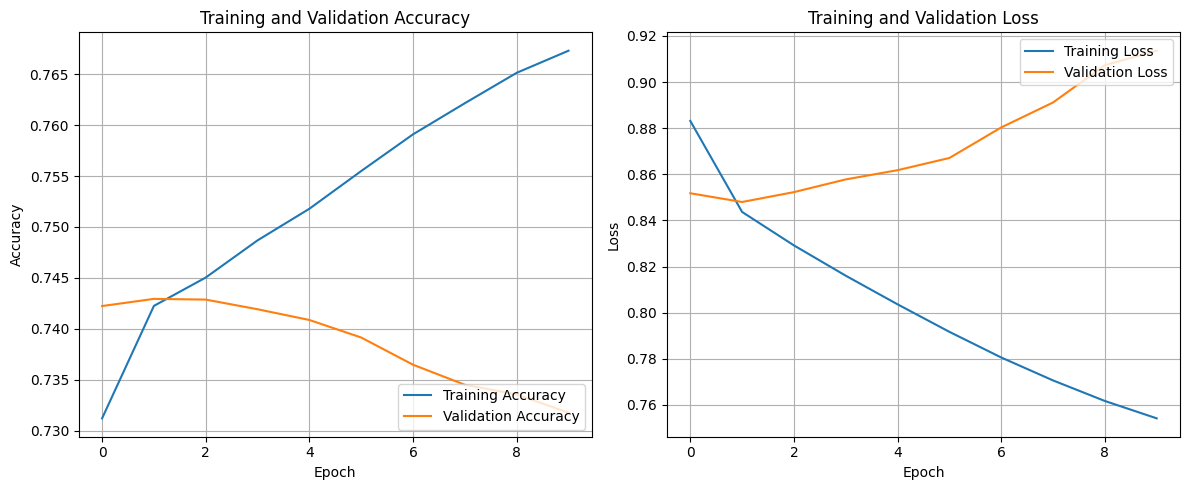

In [15]:
import matplotlib.pyplot as plt

# Get training history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()